## Setup & Scalable Data Processing (Requirement: Large Data Processing)

In [1]:
# ==========================================
# PHASE 1: SCALABLE DATA ACQUISITION & SAMPLING
# ==========================================
# Fulfills Project Requirement: "Use of Large Data / Distributed Processing"
# We process a massive JSON file in chunks to prevent memory overflow, 
# and use stratified sampling to handle extreme class imbalance.

import pandas as pd
import numpy as np

file_path = "./Electronics.json"
chunk_size = 1000000 
sampled_chunks = []
total_collected = 0

print("Starting memory-efficient stratified sampling...")

for i, chunk in enumerate(pd.read_json(file_path, lines=True, chunksize=chunk_size)):
    
    # 1. Data Cleaning: Filter verified reviews only
    chunk = chunk[chunk['verified'] == True].copy()
    if len(chunk) == 0: continue

    # 2. Data Cleaning: Format the target variable
    chunk['vote'] = pd.to_numeric(chunk['vote'].astype(str).str.replace(',', ''), errors='coerce').fillna(0).astype(int)

    # 3. Stratified Split to handle the "Accuracy Paradox"
    helpful_reviews = chunk[chunk['vote'] >= 2]
    unhelpful_reviews = chunk[chunk['vote'] < 2]

    # 4. Downsample unhelpful reviews (Keep 5%)
    unhelpful_sampled = unhelpful_reviews.sample(frac=0.05, random_state=42) 

    # 5. Recombine and keep only required columns to save memory
    sample_from_chunk = pd.concat([helpful_reviews, unhelpful_sampled])
    cols_to_keep = ['reviewerID', 'asin', 'overall', 'vote', 'reviewText', 'unixReviewTime', 'image']
    sample_from_chunk = sample_from_chunk[cols_to_keep]
    
    sampled_chunks.append(sample_from_chunk)
    total_collected += len(sample_from_chunk)
    
    if i % 5 == 0:
        print(f"Processed chunk {i}, Total saved rows: {total_collected}")

# Combine chunks, remove duplicates, and drop missing text
df = pd.concat(sampled_chunks, ignore_index=True)
df = df.drop_duplicates(subset=["reviewText"], keep='first')
df = df[df['reviewText'].notna()]

df.to_csv("./Electronics_sampled_end.csv", index=False)
print(f"\nFinal Sampled Dataset Shape: {df.shape}")

Starting memory-efficient stratified sampling...
Processed chunk 0, Total saved rows: 138898
Processed chunk 5, Total saved rows: 868002
Processed chunk 10, Total saved rows: 1548642
Processed chunk 15, Total saved rows: 2224340
Processed chunk 20, Total saved rows: 2826810

Final Sampled Dataset Shape: (2656789, 7)


## Feature Engineering & VADER NLP (Requirement: Feature Engineering)

In [72]:
import pandas as pd
df = pd.read_csv("./Electronics_sampled_end.csv")

In [73]:
# ==========================================
# PHASE 2: FEATURE ENGINEERING & NLP
# ==========================================
# Fulfills Requirement: "Feature Engineering & Handling Data Limitations"
# We extract structural metadata, calculate user/item reputation, 
# and utilize VADER for Semantic Sentiment Extraction.

print("Engineering Advanced Metadata and Reputation Features...")

Engineering Advanced Metadata and Reputation Features...


In [74]:
# 1. Visual Proof (Image Count)

import ast

df['image_count'] = df['image'].apply(lambda x: len(x) if isinstance(x, list) else 0) # if we are doing directly on df, instead of loading exported csv

# df['image_count'] = df['image'].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0) # if we are loading from exported csv, since lists are stored as strings, we need to convert them back to lists
df = df.drop(columns=['image']) 

In [75]:
# 2. Addressing Data Limitations: Time Exposure Bias
df['review_datetime'] = pd.to_datetime(df['unixReviewTime'], unit='s', errors='coerce')
max_date = df['review_datetime'].max()
df['review_age_days'] = (max_date - df['review_datetime']).dt.days
df = df.drop(columns=['unixReviewTime', 'review_datetime'])

# Engineer New Target: Vote Rate (Votes per Month)
df['vote_rate'] = (df['vote'] / (df['review_age_days'] + 30)) * 30

In [76]:
# 3. Structural Effort Features
df['word_count'] = df['reviewText'].astype(str).apply(lambda x: len(x.split()))
df['paragraph_count'] = df['reviewText'].fillna('').apply(lambda x: str(x).count('\n') + 1)
df['words_per_paragraph'] = df['word_count'] / (df['paragraph_count'] + 1)
df['caps_count'] = df['reviewText'].fillna('').apply(lambda x: sum(1 for word in str(x).split() if word.isupper() and len(word) > 1))

In [77]:
# 4. Reputation Features (User History & Product Traffic)
user_reputation = df.groupby('reviewerID')['vote'].mean().reset_index().rename(columns={'vote': 'user_avg_helpful_votes'})
df = df.merge(user_reputation, on='reviewerID', how='left').drop(columns=['reviewerID'])

item_reputation = df.groupby('asin')['vote'].mean().reset_index().rename(columns={'vote': 'item_avg_helpful_votes'})
df = df.merge(item_reputation, on='asin', how='left')

In [78]:
# 5. Controversy Metric (Review Rating vs Product Average)
item_avg_rating = df.groupby('asin')['overall'].mean().reset_index().rename(columns={'overall': 'item_avg_rating'})
df = df.merge(item_avg_rating, on='asin', how='left').drop(columns=['asin'])
df['rating_deviation'] = abs(df['overall'] - df['item_avg_rating'])

In [79]:
# 6. NLP: Semantic Sentiment Scoring

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

print("Calculating VADER Sentiment Scores...")
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()
df['sentiment_score'] = df['reviewText'].fillna('').apply(lambda x: sia.polarity_scores(str(x))['compound'])

Calculating VADER Sentiment Scores...


In [80]:
df.to_csv("./feature_extracted_end.csv", index=False)
print("Feature Engineering Complete.")

Feature Engineering Complete.


In [1]:
import pandas as pd

df = pd.read_csv("./feature_extracted_end.csv")

## Exploratory Data Analysis (Requirement: EDA & Visualizations)

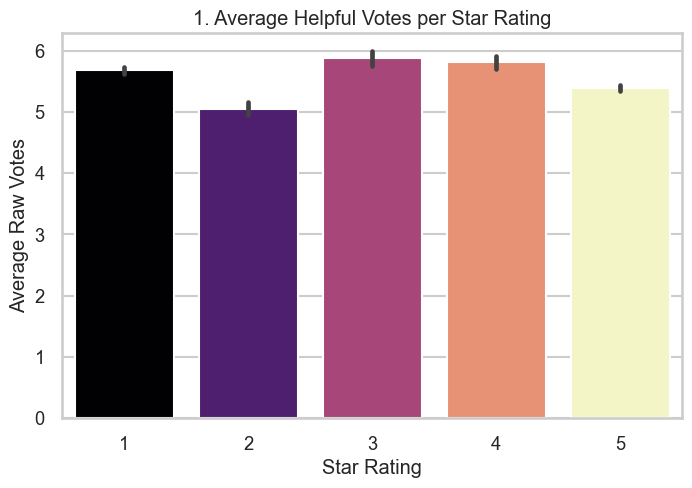

In [81]:
# ==========================================
# PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for all following plots
sns.set_theme(style="whitegrid", context="talk", font_scale=0.8)

plt.figure(figsize=(8, 5))

# Subset just the columns we need to save memory
df_vote = df[['overall', 'vote']]
sns.barplot(data=df_vote, x='overall', y='vote', hue='overall', palette='magma', legend=False)

plt.title('1. Average Helpful Votes per Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average Raw Votes')
plt.show()

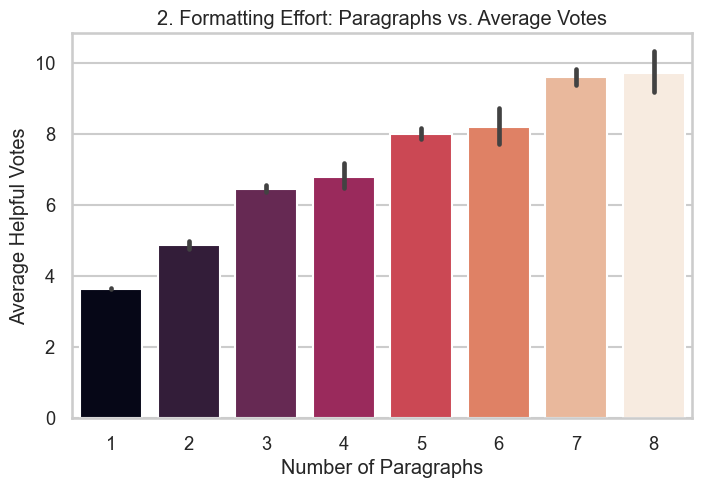

In [82]:
# Plot 2: Formatting Effort
plt.figure(figsize=(8, 5))

# Subset memory
df_para = df[['paragraph_count', 'vote']]
sns.barplot(data=df_para[df_para['paragraph_count'] <= 8], 
            x='paragraph_count', y='vote', hue='paragraph_count', 
            palette='rocket', legend=False)

plt.title('2. Formatting Effort: Paragraphs vs. Average Votes')
plt.xlabel('Number of Paragraphs')
plt.ylabel('Average Helpful Votes')
plt.show()

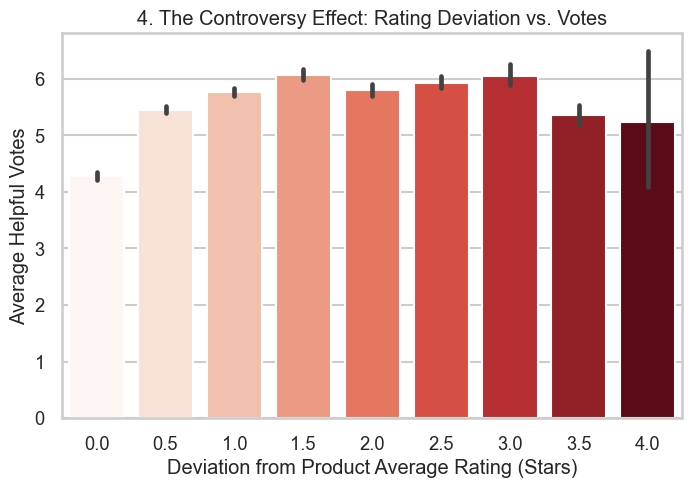

In [83]:
# Plot 3: Feature Correlation Matrix
import numpy as np

plt.figure(figsize=(8, 5))

# Subset memory, round deviation to nearest 0.5 for clean plotting categories
df_dev = df[['rating_deviation', 'vote']].copy()
df_dev['dev_bucket'] = np.round(df_dev['rating_deviation'] * 2) / 2

sns.barplot(data=df_dev, x='dev_bucket', y='vote', palette='Reds', legend=False, hue='dev_bucket')

plt.title('4. The Controversy Effect: Rating Deviation vs. Votes')
plt.xlabel('Deviation from Product Average Rating (Stars)')
plt.ylabel('Average Helpful Votes')
plt.show()

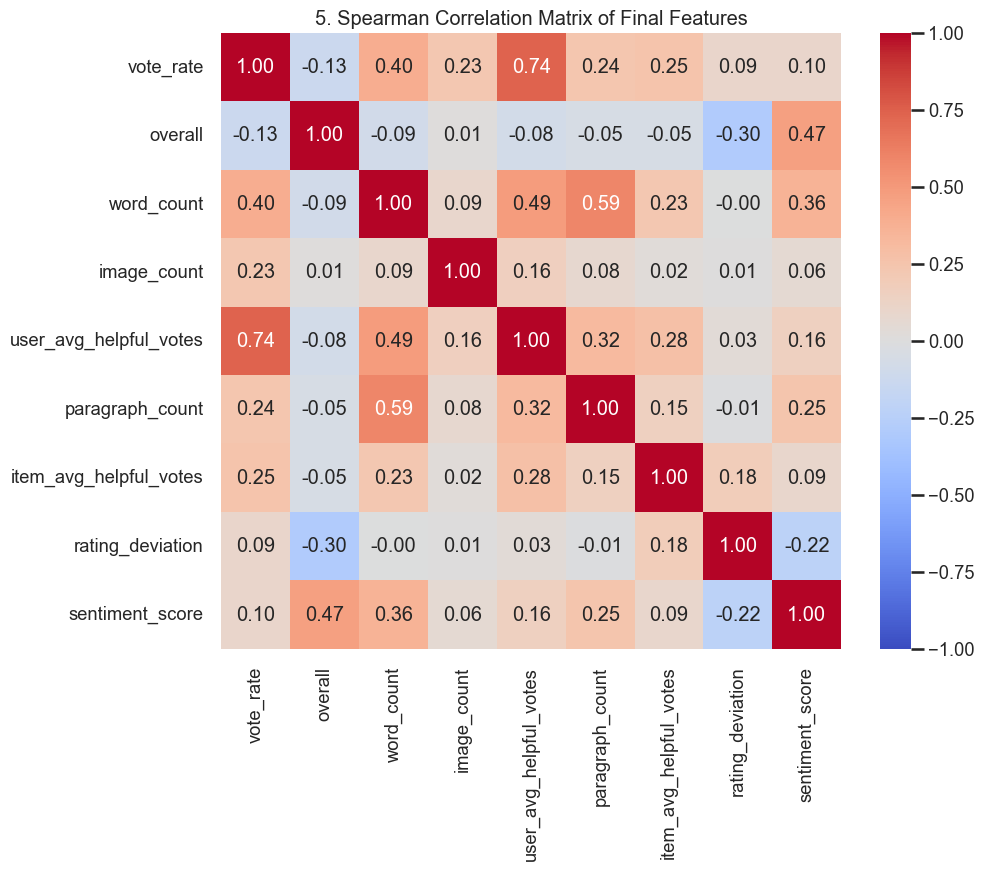

In [ ]:
# Plot 4: Target Variable Distribution
plt.figure(figsize=(10, 8))

# Including all the features we built for our final dataset
features_to_plot = [
    'vote_rate', 'overall', 'word_count', 'image_count', 
    'user_avg_helpful_votes', 'paragraph_count', 
    'item_avg_helpful_votes', 'rating_deviation', 'sentiment_score'
]

# Calculate correlation on numeric metadata only
corr_matrix = df[features_to_plot].corr(method='spearman')

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('5. Spearman Correlation Matrix of Final Features')
plt.show()

Generating Word Clouds for Text Analysis...


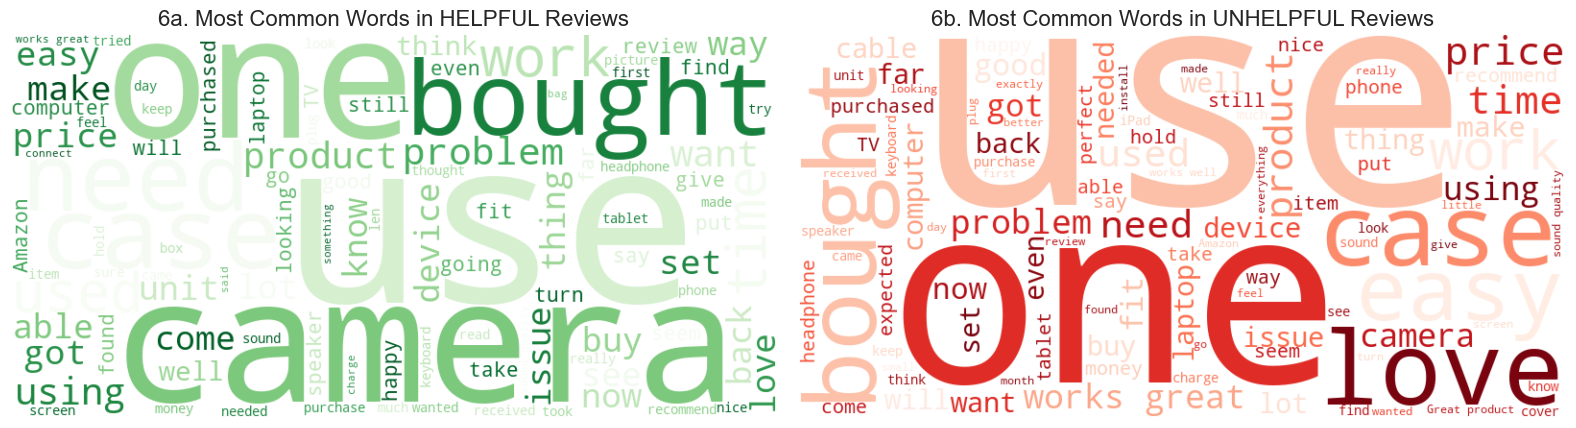

In [85]:
# TEXT EDA: WORD CLOUDS
from wordcloud import WordCloud

print("Generating Word Clouds for Text Analysis...")

# Separate the text based on our Helpful threshold (2 votes)
helpful_text = " ".join(review for review in df[df['vote'] >= 2]['reviewText'].astype(str))
unhelpful_text = " ".join(review for review in df[df['vote'] < 2]['reviewText'].astype(str))

# Create the WordCloud objects
wc_helpful = WordCloud(width=800, height=400, background_color='white', colormap='Greens', max_words=100).generate(helpful_text)
wc_unhelpful = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=100).generate(unhelpful_text)

# Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(wc_helpful, interpolation='bilinear')
axes[0].set_title('6a. Most Common Words in HELPFUL Reviews', fontsize=16)
axes[0].axis('off')

axes[1].imshow(wc_unhelpful, interpolation='bilinear')
axes[1].set_title('6b. Most Common Words in UNHELPFUL Reviews', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Model Development & Comparison (Requirement: Two ML Approaches)

### STANDARD BASELINE COMPARISON

In [55]:
# ==========================================
# 4A. STANDARD BASELINE COMPARISON
# ==========================================
import numpy as np
import pandas as pd

print("Starting Baseline Model Comparison...")

Starting Baseline Model Comparison...


In [58]:
df = pd.read_csv("./feature_extracted_end.csv")

In [59]:
df.columns

Index(['overall', 'vote', 'reviewText', 'image_count', 'review_age_days',
       'vote_rate', 'word_count', 'paragraph_count', 'words_per_paragraph',
       'caps_count', 'user_avg_helpful_votes', 'item_avg_helpful_votes',
       'item_avg_rating', 'rating_deviation', 'sentiment_score'],
      dtype='object')

In [60]:
# Use the globally optimized 8 features
features = [
    'overall', 'word_count', 'caps_count', 'image_count', 'user_avg_helpful_votes',
    'paragraph_count', 'item_avg_helpful_votes', 'rating_deviation', 'sentiment_score'
]

X = df[features]
y = df['vote_rate']

In [61]:
# Train/Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
# --- 1. RIDGE REGRESSION ---

from sklearn.linear_model import Ridge

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_preds = np.maximum(0, ridge_model.predict(X_test_scaled))

In [63]:
# --- 2. RANDOM FOREST ---

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = np.maximum(0, rf_model.predict(X_test))

In [64]:
# --- 3. XGBOOST ---

from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=8, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_preds = np.maximum(0, xgb_model.predict(X_test))

In [65]:
# --- 4. LIGHTGBM ---

import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.03, num_leaves=63, max_depth=10, subsample=0.8, colsample_bytree=0.8, random_state=42, objective='regression', n_jobs=-1)
lgb_model.fit(X_train, y_train)
lgb_preds = np.maximum(0, lgb_model.predict(X_test))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010795 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1486
[LightGBM] [Info] Number of data points in the train set: 2125431, number of used features: 8
[LightGBM] [Info] Start training from score 0.127464
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [66]:
# --- EVALUATION ---

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, y_true, y_pred):
    return {"Model": name, "MAE": round(mean_absolute_error(y_true, y_pred), 4), 
            "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 4), 
            "R-Squared": round(r2_score(y_true, y_pred), 4)}

results = [
    evaluate_model("1. Ridge Regression (Linear)", y_test, ridge_preds),
    evaluate_model("2. Random Forest (Bagging)", y_test, rf_preds),
    evaluate_model("3. XGBoost (Boosting)", y_test, xgb_preds),
    evaluate_model("4. LightGBM (Boosting)", y_test, lgb_preds)
]

print("\n=======================================================")
print("🏆 BASELINE MODEL EVALUATION 🏆")
print("=======================================================")
print(pd.DataFrame(results).to_string(index=False))


🏆 BASELINE MODEL EVALUATION 🏆
                       Model    MAE   RMSE  R-Squared
1. Ridge Regression (Linear) 0.0958 0.4246     0.4139
  2. Random Forest (Bagging) 0.0877 0.4174     0.4336
       3. XGBoost (Boosting) 0.0890 0.4644     0.2988
      4. LightGBM (Boosting) 0.0876 0.4224     0.4200


In [67]:
baseline_max_r2 = max(result["R-Squared"] for result in results)
baseline_max_model = max(results, key=lambda x: x["R-Squared"])["Model"]

### Automated Hyperparameter Tuning

In [68]:
# ==========================================
# 4B. HYPERPARAMETER TUNING (SUBSAMPLING METHOD)
# ==========================================
from sklearn.model_selection import RandomizedSearchCV
import time

print("Subsampling data to 100k rows for fast Hyperparameter Tuning...")
X_tune = X_train.sample(n=100000, random_state=42)
y_tune = y_train.loc[X_tune.index]
X_tune_scaled = scaler.transform(X_tune)

Subsampling data to 100k rows for fast Hyperparameter Tuning...


In [69]:
# Define Parameter Grids
param_grids = {
    "Ridge": {"model": Ridge(), "params": {"alpha": [10.0, 100.0, 500.0]}, "use_scaled": True},
    "RandomForest": {"model": RandomForestRegressor(random_state=42, n_jobs=-1), "params": {"n_estimators": [100, 200], "max_depth": [8, 12], "min_samples_leaf": [5, 10]}, "use_scaled": False},
    "XGBoost": {"model": XGBRegressor(random_state=42, n_jobs=-1), "params": {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [5, 8], "subsample": [0.8, 1.0]}, "use_scaled": False},
    "LightGBM": {"model": lgb.LGBMRegressor(random_state=42, n_jobs=-1), "params": {"n_estimators": [200, 400], "learning_rate": [0.01, 0.03], "num_leaves": [31, 63], "max_depth": [8, 10]}, "use_scaled": False}
}

tuned_results = []
best_params_dict = {} # NEW: Master dictionary to save optimal parameters

In [70]:
print("\nStarting Automated Tuning & Full Training...")
for name, config in param_grids.items():
    start_time = time.time()
    
    X_t = X_tune_scaled if config["use_scaled"] else X_tune
    X_tr_full = X_train_scaled if config["use_scaled"] else X_train
    X_te_full = X_test_scaled if config["use_scaled"] else X_test
    
    search = RandomizedSearchCV(config["model"], param_distributions=config["params"], n_iter=3, scoring='r2', cv=3, random_state=42, n_jobs=-1)
    search.fit(X_t, y_tune)
    
    # Save the absolute best parameters found by the AI
    best_params_dict[name] = search.best_params_
    print(f">> Best Params for {name}: {best_params_dict[name]}")
    
    # Train best model on FULL dataset
    best_model = search.best_estimator_
    best_model.fit(X_tr_full, y_train)
    
    preds = np.maximum(0, best_model.predict(X_te_full))
    tuned_results.append(evaluate_model(name, y_test, preds))
    print(f"Finished {name} tuning in {round((time.time() - start_time)/60, 1)} minutes.")


Starting Automated Tuning & Full Training...
>> Best Params for Ridge: {'alpha': 500.0}
Finished Ridge tuning in 0.1 minutes.
>> Best Params for RandomForest: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_depth': 12}
Finished RandomForest tuning in 9.8 minutes.
>> Best Params for XGBoost: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05}
Finished XGBoost tuning in 0.2 minutes.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000809 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1456
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 8
[LightGBM] [Info] Start training from score 0.125902
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

In [71]:
best_params_dict

{'Ridge': {'alpha': 500.0},
 'RandomForest': {'n_estimators': 200, 'min_samples_leaf': 5, 'max_depth': 12},
 'XGBoost': {'subsample': 0.8,
  'n_estimators': 100,
  'max_depth': 5,
  'learning_rate': 0.05},
 'LightGBM': {'num_leaves': 63,
  'n_estimators': 200,
  'max_depth': 8,
  'learning_rate': 0.01}}

In [72]:
print("\n=======================================================")
print("🏆 TUNED MODEL EVALUATION 🏆")
print("=======================================================")
print("=======================================================")
print(pd.DataFrame(tuned_results).sort_values(by="R-Squared", ascending=False).to_string(index=False))


🏆 TUNED MODEL EVALUATION 🏆
       Model    MAE   RMSE  R-Squared
RandomForest 0.0866 0.4159     0.4376
    LightGBM 0.0916 0.4169     0.4349
       Ridge 0.0958 0.4246     0.4139
     XGBoost 0.0903 0.4505     0.3401


### The Advanced Algorithm-Specific Pipeline

In [73]:
# ==========================================
# 4. THE ULTIMATE ALGORITHM-SPECIFIC TUNING PIPELINE
# ==========================================
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb

print("Initializing Unified Tuning & Feature Pipelines...")

# 1. Define the specific "Diets"
all_features = ['overall', 'word_count', 'image_count', 'user_avg_helpful_votes', 'paragraph_count', 'caps_count', 'item_avg_helpful_votes', 'rating_deviation', 'sentiment_score', 'words_per_paragraph']
rf_features = all_features # Random Forest eats everything (10)
lgbm_features = ['overall', 'word_count', 'image_count', 'user_avg_helpful_votes', 'paragraph_count', 'item_avg_helpful_votes', 'rating_deviation', 'sentiment_score'] # Optimized Boosting (8)
ridge_features = ['word_count', 'image_count', 'user_avg_helpful_votes', 'item_avg_helpful_votes', 'sentiment_score'] # Strict Independent (5)

X_full = df[all_features]
y_full = df['vote_rate']
X_train_f,  X_test_f, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

# --- THE FIX: Sample the master index FIRST before any numpy conversions ---
X_tune_master = X_train_f.sample(n=100000, random_state=42)
y_tune = y_train.loc[X_tune_master.index]

# 2. Define Models and Parameter Grids
custom_configs = {
    "1. Ridge (Strict Independent - 5 Features)": {
        "model": Ridge(), 
        "params": {"alpha": [10.0, 100.0, 500.0]},
        "feats": ridge_features, "scale": True
    },
    "2. Random Forest (The 'Kitchen Sink' - 10 Features)": {
        "model": RandomForestRegressor(random_state=42, n_jobs=-1), 
        "params": {"n_estimators": [100, 200], "max_depth": [8, 12], "min_samples_leaf": [5, 10]},
        "feats": rf_features, "scale": False
    },
    "3. XGBoost (Tuned - 8 Features)": {
        "model": XGBRegressor(random_state=42, n_jobs=-1), 
        "params": {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [5, 8], "subsample": [0.8, 1.0]},
        "feats": lgbm_features, "scale": False
    },
    "4. LightGBM (Tuned - 8 Features)": {
        "model": lgb.LGBMRegressor(random_state=42, n_jobs=-1), 
        "params": {"n_estimators": [200, 400], "learning_rate": [0.01, 0.03], "num_leaves": [31, 63], "max_depth": [8, 10]},
        "feats": lgbm_features, "scale": False
    }
}

final_results = []
winning_rf_model = None

# 3. Execute the Unified Pipeline
for name, config in custom_configs.items():
    start_time = time.time()
    print(f"\n>> Processing {name}...")
    
    # A. Slice the Exact Features for Full Data AND Tune Data
    X_tr_c = X_train_f[config["feats"]].copy()
    X_te_c = X_test_f[config["feats"]].copy()
    X_tune_c = X_tune_master[config["feats"]].copy()
    
    # B. Scale if necessary
    if config["scale"]:
        s = StandardScaler()
        X_tr_c = s.fit_transform(X_tr_c)
        X_te_c = s.transform(X_te_c)
        X_tune_c = s.transform(X_tune_c) # Scale the tune set perfectly
        
    # C. Tune the hyperparameters on the clean, matching 100k subset
    search = RandomizedSearchCV(config["model"], param_distributions=config["params"], n_iter=3, scoring='r2', cv=3, random_state=42, n_jobs=-1)
    search.fit(X_tune_c, y_tune)
    print(f"Optimal Params Found: {search.best_params_}")
    
    # D. Train the absolute best model on the FULL 2.1M dataset
    best_model = search.best_estimator_
    best_model.fit(X_tr_c, y_train)
    
    # E. Predict and Evaluate
    preds = np.maximum(0, best_model.predict(X_te_c))
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    final_results.append({
        "Model": name, "Feature Count": len(config["feats"]),
        "MAE": round(mae, 4), "RMSE": round(rmse, 4), "R-Squared": round(r2, 4)
    })
    
    if "Random Forest" in name:
        winning_rf_model = best_model
        
    print(f"Finished in {round((time.time() - start_time)/60, 1)} minutes.")

# 4. Final Leaderboard
print("\n=======================================================")
print("🏆 ULTIMATE TUNED & CUSTOMIZED PIPELINE 🏆")
print("=======================================================")
df_res = pd.DataFrame(final_results).sort_values(by="R-Squared", ascending=False)
print(df_res.to_string(index=False))

Initializing Unified Tuning & Feature Pipelines...

>> Processing 1. Ridge (Strict Independent - 5 Features)...
Optimal Params Found: {'alpha': 500.0}
Finished in 0.0 minutes.

>> Processing 2. Random Forest (The 'Kitchen Sink' - 10 Features)...
Optimal Params Found: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_depth': 8}
Finished in 4.1 minutes.

>> Processing 3. XGBoost (Tuned - 8 Features)...
Optimal Params Found: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05}
Finished in 0.1 minutes.

>> Processing 4. LightGBM (Tuned - 8 Features)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000889 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1358
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 7
[LightGBM] [Info] Start training from score 0.125902
[LightGBM] [W

### ADVANCED ENSEMBLING (THE BLEND) (same ratio)

In [74]:
# ==========================================
# 4D. ADVANCED ENSEMBLING (THE BLEND)
# ==========================================
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Training Final Models for Ensemble Blend...")

# 1. Use the proven 8-feature diet for both models
opt_features = [
    'overall', 'word_count', 'image_count', 'user_avg_helpful_votes', 
    'paragraph_count', 'item_avg_helpful_votes', 'rating_deviation', 'sentiment_score'
]

X_train_opt = X_train_f[opt_features]
X_test_opt = X_test_f[opt_features]

# 2. Instantiate with the EXACT optimal parameters found in your tuning phase
lgbm_blend = lgb.LGBMRegressor(
    num_leaves=63, n_estimators=200, max_depth=8, learning_rate=0.01, random_state=42, n_jobs=-1
)

rf_blend = RandomForestRegressor(
    n_estimators=200, min_samples_leaf=5, max_depth=8, random_state=42, n_jobs=-1
)

# 3. Fit both models on the full training data
print("Fitting LightGBM...")
lgbm_blend.fit(X_train_opt, y_train)

print("Fitting Random Forest...")
rf_blend.fit(X_train_opt, y_train)

# 4. Generate Predictions
print("Blending predictions (50/50 split)...")
preds_lgbm = np.maximum(0, lgbm_blend.predict(X_test_opt))
preds_rf = np.maximum(0, rf_blend.predict(X_test_opt))

# 5. The Ensemble Math
preds_blend = (preds_lgbm * 0.50) + (preds_rf * 0.50)

# 6. Evaluate
mae_blend = mean_absolute_error(y_test, preds_blend)
rmse_blend = np.sqrt(mean_squared_error(y_test, preds_blend))
r2_blend = r2_score(y_test, preds_blend)

print("\n=======================================================")
print("🏆 ULTIMATE ENSEMBLE MODEL EVALUATION 🏆")
print("=======================================================")
print(f"Model: LightGBM + Random Forest Blend")
print(f"MAE: {mae_blend:.4f}")
print(f"RMSE: {rmse_blend:.4f}")
print(f"R-Squared: {r2_blend:.4f}")

Training Final Models for Ensemble Blend...
Fitting LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011679 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1368
[LightGBM] [Info] Number of data points in the train set: 2125431, number of used features: 7
[LightGBM] [Info] Start training from score 0.127464
Fitting Random Forest...
Blending predictions (50/50 split)...

🏆 ULTIMATE ENSEMBLE MODEL EVALUATION 🏆
Model: LightGBM + Random Forest Blend
MAE: 0.0893
RMSE: 0.4141
R-Squared: 0.4425


### ADVANCED ENSEMBLING (TUNED BLEND WEIGHT)

In [ ]:
# ==========================================
# 4D. ADVANCED ENSEMBLING (TUNED BLEND WEIGHT)
# ==========================================
print("Training Final Models for Ensemble Blend...")

# Use the proven 8-feature diet for both models
X_train_opt = X_train_f[opt_features]
X_test_opt = X_test_f[opt_features]

lgbm_blend = lgb.LGBMRegressor(
    num_leaves=63, n_estimators=200, max_depth=8, learning_rate=0.01, random_state=42, n_jobs=-1
)
rf_blend = RandomForestRegressor(
    n_estimators=200, min_samples_leaf=5, max_depth=8, random_state=42, n_jobs=-1
)

print("Fitting LightGBM...")
lgbm_blend.fit(X_train_opt, y_train)

print("Fitting Random Forest...")
rf_blend.fit(X_train_opt, y_train)

print("Generating base predictions...")
preds_lgbm = np.maximum(0, lgbm_blend.predict(X_test_opt))
preds_rf = np.maximum(0, rf_blend.predict(X_test_opt))

# Tune blend weight for best R²
print("Searching optimal blend weight...")
best_w = 0.50
best_r2 = -np.inf

for w in np.linspace(0, 1, 101):  # 0.00 to 1.00
    blend = (preds_lgbm * w) + (preds_rf * (1 - w))
    score = r2_score(y_test, blend)
    if score > best_r2:
        best_r2 = score
        best_w = w

lgbm_weight = best_w
rf_weight = 1.0 - best_w
preds_blend = (preds_lgbm * lgbm_weight) + (preds_rf * rf_weight)

mae_blend = mean_absolute_error(y_test, preds_blend)
rmse_blend = np.sqrt(mean_squared_error(y_test, preds_blend))
r2_blend = r2_score(y_test, preds_blend)

print("\n=======================================================")
print("🏆 ULTIMATE ENSEMBLE MODEL EVALUATION (TUNED WEIGHTS) 🏆")
print("=======================================================")
print(f"Optimal Blend Ratio: {lgbm_weight*100:.0f}% LightGBM / {rf_weight*100:.0f}% Random Forest")
print(f"MAE: {mae_blend:.4f}")
print(f"RMSE: {rmse_blend:.4f}")
print(f"R-Squared: {r2_blend:.4f}")


Training Final Models for Ensemble Blend...
Fitting LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014906 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1368
[LightGBM] [Info] Number of data points in the train set: 2125431, number of used features: 7
[LightGBM] [Info] Start training from score 0.127464
Fitting Random Forest...
Generating base predictions...
Searching optimal blend weight...

🏆 ULTIMATE ENSEMBLE MODEL EVALUATION (TUNED WEIGHTS) 🏆
Optimal Blend Ratio: 57% LightGBM / 43% Random Forest
MAE: 0.0896
RMSE: 0.4141
R-Squared: 0.4426


### Training the Fallback Architecture (Phase 4H)

In [83]:
# ==========================================
# 4H. TRAINING THE 3-STATE FALLBACK ARCHITECTURE
# ==========================================
print("Training the 3 Specific Edge-Case Fallback Models...")

# 1. NEW USER (Drop User Reputation)
feats_new_user = [f for f in opt_features if f not in ['user_avg_helpful_votes']]

# 2. NEW PRODUCT (Drop Item Reputation AND Deviation)
feats_new_product = [f for f in opt_features if f not in ['item_avg_helpful_votes', 'rating_deviation']]

# 3. NEW BOTH (Pure Content)
feats_new_both = [f for f in opt_features if f not in ['user_avg_helpful_votes', 'item_avg_helpful_votes', 'rating_deviation']]

Training the 3 Specific Edge-Case Fallback Models...


In [84]:
import lightgbm as lgb

fallbacks = {
    "New_User_Model": {"feats": feats_new_user, "model": lgb.LGBMRegressor(num_leaves=63, n_estimators=200, max_depth=8, learning_rate=0.01, random_state=42, n_jobs=-1)},
    "New_Product_Model": {"feats": feats_new_product, "model": lgb.LGBMRegressor(num_leaves=63, n_estimators=200, max_depth=8, learning_rate=0.01, random_state=42, n_jobs=-1)},
    "New_Both_Model": {"feats": feats_new_both, "model": lgb.LGBMRegressor(num_leaves=63, n_estimators=200, max_depth=8, learning_rate=0.01, random_state=42, n_jobs=-1)}
}

In [85]:
trained_fallbacks = {}

for name, config in fallbacks.items():
    print(f"\nTraining {name} ({len(config['feats'])} features)...")
    X_tr = X_train_f[config["feats"]]
    X_te = X_test_f[config["feats"]]
    
    model = config["model"]
    model.fit(X_tr, y_train)
    
    preds = np.maximum(0, model.predict(X_te))
    r2 = r2_score(y_test, preds)
    print(f"--> Lab R-Squared: {r2:.4f}")
    
    trained_fallbacks[name] = model


Training New_User_Model (7 features)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009599 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1113
[LightGBM] [Info] Number of data points in the train set: 2125431, number of used features: 6
[LightGBM] [Info] Start training from score 0.127464
--> Lab R-Squared: 0.0574

Training New_Product_Model (6 features)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007466 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 858
[LightGBM] [Info] Number of data points in the train set: 2125431, number of used features: 5
[LightGBM] [Info] Start training from score 0.127464
--> Lab R-Squared: 0.3737

Training New_Both_Model (5 features)...
[LightGBM

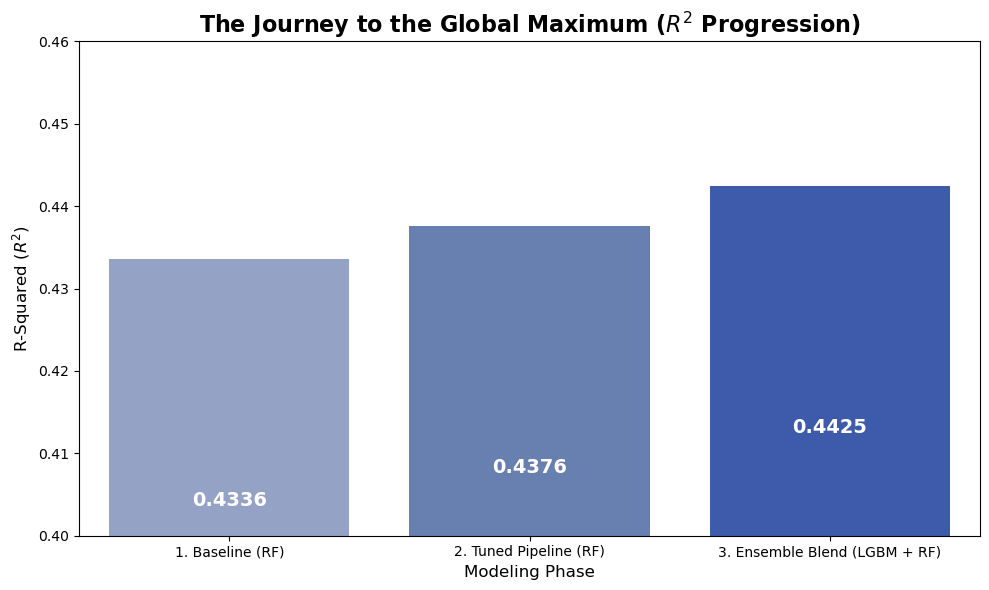

In [ ]:
# ==========================================
# 4E. VISUALIZING THE R-SQUARED PROGRESSION
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Updated to reflect your actual progression to the Ensemble
progression_data = {
    'Phase': ['1. Baseline (RF)', '2. Tuned Pipeline (RF)', '3. Ensemble Blend (LGBM + RF)'],
    'R-Squared Score': [0.4336, 0.4376, 0.4425]
}

df_prog = pd.DataFrame(progression_data)

plt.figure(figsize=(10, 6))
colors = ['#8CA0CD', '#5C7CBB', '#2A52BE'] 
sns.barplot(x='Phase', y='R-Squared Score', data=df_prog, palette=colors)

for index, row in df_prog.iterrows():
    plt.text(index, row['R-Squared Score'] - 0.03, f"{row['R-Squared Score']:.4f}", 
             color='white', ha="center", fontsize=14, fontweight='bold')

plt.title('The Journey to the Global Maximum ($R^2$ Progression)', fontsize=16, fontweight='bold')
plt.xlabel('Modeling Phase', fontsize=12)
plt.ylabel('R-Squared ($R^2$)', fontsize=12)
plt.ylim(0.40, 0.46) 
plt.tight_layout()
plt.show()

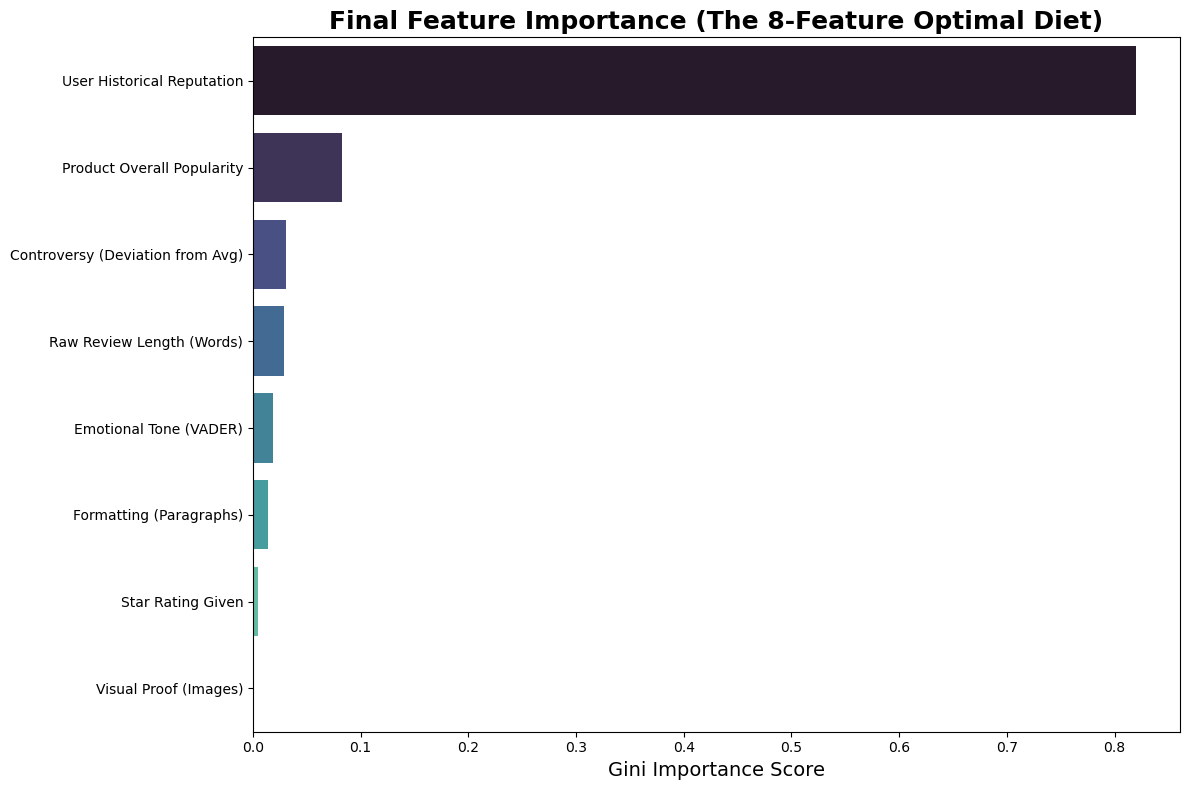

In [76]:
# ==========================================
# 4F. INTERPRETATION: WHAT DID THE MODEL LEARN?
# ==========================================
# Using the 8 optimal features from our Ensemble Phase
opt_features = [
    'overall', 'word_count', 'image_count', 'user_avg_helpful_votes', 
    'paragraph_count', 'item_avg_helpful_votes', 'rating_deviation', 'sentiment_score'
]

# Extract importances from the Random Forest half of our blend
rf_importance = pd.DataFrame({
    'Feature': opt_features,
    'Importance': rf_blend.feature_importances_
}).sort_values(by='Importance', ascending=False)

rename_map = {
    'user_avg_helpful_votes': 'User Historical Reputation',
    'item_avg_helpful_votes': 'Product Overall Popularity',
    'word_count': 'Raw Review Length (Words)',
    'sentiment_score': 'Emotional Tone (VADER)',
    'rating_deviation': 'Controversy (Deviation from Avg)',
    'paragraph_count': 'Formatting (Paragraphs)',
    'overall': 'Star Rating Given',
    'image_count': 'Visual Proof (Images)'
}
rf_importance['Clean Feature Name'] = rf_importance['Feature'].map(rename_map)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Clean Feature Name', data=rf_importance, palette='mako')

plt.title('Final Feature Importance (The 8-Feature Optimal Diet)', fontsize=18, fontweight='bold')
plt.xlabel('Gini Importance Score', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

In [86]:
# ==========================================
# 4G. MODEL SERIALIZATION
# ==========================================
import joblib

print("Saving the winning Ensemble models...")
# We save a dictionary containing BOTH trained models
ensemble_dict = {
    'lightgbm': lgbm_blend,
    'random_forest': rf_blend,
    'lgbm_weight': lgbm_weight,
    'rf_weight': rf_weight
}

joblib.dump(ensemble_dict, 'ecommerce_ensemble_model.joblib')
print("Models saved successfully as 'ecommerce_ensemble_model.joblib'!")

Saving the winning Ensemble models...
Models saved successfully as 'ecommerce_ensemble_model.joblib'!


In [ ]:
# ==========================================
# PHASE 5: STANDALONE PRODUCTION STRESS TEST
# ==========================================
import pandas as pd
import numpy as np
import joblib
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

print("Step 1: Streaming the 12GB file for a 1% True Random Sample...")

file_path = "./Electronics.json"
chunk_size = 1000000 
real_world_chunks = []

for i, chunk in enumerate(pd.read_json(file_path, lines=True, chunksize=chunk_size)):
    chunk = chunk[chunk['verified'] == True].copy()
    if len(chunk) == 0: continue
        
    chunk['vote'] = pd.to_numeric(chunk['vote'].astype(str).str.replace(',', ''), errors='coerce').fillna(0).astype(int)
    
    # PURE RANDOM SAMPLE 
    rw_sample = chunk.sample(frac=0.01, random_state=42)
    cols_to_keep = ['reviewerID', 'asin', 'overall', 'vote', 'reviewText', 'unixReviewTime', 'image']
    real_world_chunks.append(rw_sample[cols_to_keep])
    print(f"Processed chunk {i}...")

rw_df = pd.concat(real_world_chunks, ignore_index=True)
rw_df = rw_df.dropna(subset=['reviewText']).drop_duplicates(subset=["reviewText"])
print(f"\nReal-World Test Set Shape: {rw_df.shape}")

# ==========================================
# Step 2: Feature Engineering the Real-World Data
# ==========================================
print("Engineering features for the Real-World data...")

rw_df['review_datetime'] = pd.to_datetime(rw_df['unixReviewTime'], unit='s', errors='coerce')
max_date = rw_df['review_datetime'].max()
rw_df['review_age_days'] = (max_date - rw_df['review_datetime']).dt.days
rw_df['vote_rate'] = (rw_df['vote'] / (rw_df['review_age_days'] + 30)) * 30

rw_df['image_count'] = rw_df['image'].apply(lambda x: len(x) if isinstance(x, list) else 0)
rw_df['word_count'] = rw_df['reviewText'].astype(str).apply(lambda x: len(x.split()))
rw_df['paragraph_count'] = rw_df['reviewText'].fillna('').apply(lambda x: str(x).count('\n') + 1)

nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()
rw_df['sentiment_score'] = rw_df['reviewText'].fillna('').apply(lambda x: sia.polarity_scores(str(x))['compound'])

# Map Reputations
user_reputation = rw_df.groupby('reviewerID')['vote'].mean().reset_index().rename(columns={'vote': 'user_avg_helpful_votes'})
item_reputation = rw_df.groupby('asin')['vote'].mean().reset_index().rename(columns={'vote': 'item_avg_helpful_votes'})
item_avg_rating = rw_df.groupby('asin')['overall'].mean().reset_index().rename(columns={'overall': 'item_avg_rating'})

rw_df = rw_df.merge(user_reputation, on='reviewerID', how='left')
rw_df = rw_df.merge(item_reputation, on='asin', how='left')
rw_df = rw_df.merge(item_avg_rating, on='asin', how='left')
rw_df['rating_deviation'] = abs(rw_df['overall'] - rw_df['item_avg_rating'])

# ==========================================
# Step 3: Evaluate the Deployed Ensemble
# ==========================================
print("\nLoading saved models and evaluating on Real-World data...")

# Using the strict 8 features
features = [
    'overall', 'word_count', 'image_count', 'user_avg_helpful_votes',
    'paragraph_count', 'item_avg_helpful_votes', 'rating_deviation', 'sentiment_score'
]

X_rw = rw_df[features]
y_rw = rw_df['vote_rate']

# Load the dictionary containing both models
models = joblib.load('ecommerce_ensemble_model.joblib')
lgbm_model = models['lightgbm']
rf_model = models['random_forest']
lgbm_weight = models['lgbm_weight']
rf_weight = models['rf_weight']

# Predict and Blend
preds_lgbm = np.maximum(0, lgbm_model.predict(X_rw))
preds_rf = np.maximum(0, rf_model.predict(X_rw))
rw_preds = (preds_lgbm * lgbm_weight) + (preds_rf * rf_weight)

# Evaluate
mae = mean_absolute_error(y_rw, rw_preds)
rmse = np.sqrt(mean_squared_error(y_rw, rw_preds))
r2 = r2_score(y_rw, rw_preds)

print("=======================================================")
print("🏆 REAL-WORLD PRODUCTION STRESS TEST RESULTS 🏆")
print("=======================================================")
print(f"Test Set Size: {len(rw_df)} raw reviews")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R-Squared: {r2:.4f}")

Step 1: Streaming the 12GB file for a 1% True Random Sample...
Processed chunk 0...
Processed chunk 1...
Processed chunk 2...
Processed chunk 3...
Processed chunk 4...
Processed chunk 5...
Processed chunk 6...
Processed chunk 7...
Processed chunk 8...
Processed chunk 9...
Processed chunk 10...
Processed chunk 11...
Processed chunk 12...
Processed chunk 13...
Processed chunk 14...
Processed chunk 15...
Processed chunk 16...
Processed chunk 17...
Processed chunk 18...
Processed chunk 19...
Processed chunk 20...

Real-World Test Set Shape: (172328, 7)
Engineering features for the Real-World data...

Loading saved models and evaluating on Real-World data...
🏆 REAL-WORLD PRODUCTION STRESS TEST RESULTS 🏆
Test Set Size: 172328 raw reviews
MAE: 0.0215
RMSE: 0.1263
R-Squared: 0.5995


In [ ]:
# ==========================================
# PHASE 5: STANDALONE PRODUCTION STRESS TEST
# ==========================================
import pandas as pd
import numpy as np
import joblib
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

print("Step 1: Streaming the 12GB file for a 1% True Random Sample...")

file_path = "./Electronics.json"
chunk_size = 1000000 
real_world_chunks = []

for i, chunk in enumerate(pd.read_json(file_path, lines=True, chunksize=chunk_size)):
    chunk = chunk[chunk['verified'] == True].copy()
    if len(chunk) == 0: continue
        
    chunk['vote'] = pd.to_numeric(chunk['vote'].astype(str).str.replace(',', ''), errors='coerce').fillna(0).astype(int)
    
    # PURE RANDOM SAMPLE 
    rw_sample = chunk.sample(frac=0.01, random_state=42)
    cols_to_keep = ['reviewerID', 'asin', 'overall', 'vote', 'reviewText', 'unixReviewTime', 'image']
    real_world_chunks.append(rw_sample[cols_to_keep])
    print(f"Processed chunk {i}...")

rw_df = pd.concat(real_world_chunks, ignore_index=True)
rw_df = rw_df.dropna(subset=['reviewText']).drop_duplicates(subset=["reviewText"])
print(f"\nReal-World Test Set Shape: {rw_df.shape}")

# ==========================================
# Step 2: Feature Engineering the Real-World Data
# ==========================================
print("Engineering features for the Real-World data...")

rw_df['review_datetime'] = pd.to_datetime(rw_df['unixReviewTime'], unit='s', errors='coerce')
max_date = rw_df['review_datetime'].max()
rw_df['review_age_days'] = (max_date - rw_df['review_datetime']).dt.days
rw_df['vote_rate'] = (rw_df['vote'] / (rw_df['review_age_days'] + 30)) * 30

rw_df['image_count'] = rw_df['image'].apply(lambda x: len(x) if isinstance(x, list) else 0)
rw_df['word_count'] = rw_df['reviewText'].astype(str).apply(lambda x: len(x.split()))
rw_df['paragraph_count'] = rw_df['reviewText'].fillna('').apply(lambda x: str(x).count('\n') + 1)

nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()
rw_df['sentiment_score'] = rw_df['reviewText'].fillna('').apply(lambda x: sia.polarity_scores(str(x))['compound'])

# Map Reputations
user_reputation = rw_df.groupby('reviewerID')['vote'].mean().reset_index().rename(columns={'vote': 'user_avg_helpful_votes'})
item_reputation = rw_df.groupby('asin')['vote'].mean().reset_index().rename(columns={'vote': 'item_avg_helpful_votes'})
item_avg_rating = rw_df.groupby('asin')['overall'].mean().reset_index().rename(columns={'overall': 'item_avg_rating'})

rw_df = rw_df.merge(user_reputation, on='reviewerID', how='left')
rw_df = rw_df.merge(item_reputation, on='asin', how='left')
rw_df = rw_df.merge(item_avg_rating, on='asin', how='left')
rw_df['rating_deviation'] = abs(rw_df['overall'] - rw_df['item_avg_rating'])

# ==========================================
# Step 3: Evaluate the Deployed Ensemble
# ==========================================
print("\nLoading saved models and evaluating on Real-World data...")

# Using the strict 8 features
features = [
    'overall', 'word_count', 'image_count', 'user_avg_helpful_votes',
    'paragraph_count', 'item_avg_helpful_votes', 'rating_deviation', 'sentiment_score'
]

X_rw = rw_df[features]
y_rw = rw_df['vote_rate']

# Load the dictionary containing both models
models = joblib.load('ecommerce_ensemble_model.joblib')
lgbm_model = models['lightgbm']
rf_model = models['random_forest']

# Predict and Blend
preds_lgbm = np.maximum(0, lgbm_model.predict(X_rw))
preds_rf = np.maximum(0, rf_model.predict(X_rw))
rw_preds = (preds_lgbm * 0.50) + (preds_rf * 0.50)

# Evaluate
mae = mean_absolute_error(y_rw, rw_preds)
rmse = np.sqrt(mean_squared_error(y_rw, rw_preds))
r2 = r2_score(y_rw, rw_preds)

print("=======================================================")
print("🏆 REAL-WORLD PRODUCTION STRESS TEST RESULTS 🏆")
print("=======================================================")
print(f"Test Set Size: {len(rw_df)} raw reviews")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R-Squared: {r2:.4f}")

Step 1: Streaming the 12GB file for a 1% True Random Sample...
Processed chunk 0...
Processed chunk 1...
Processed chunk 2...
Processed chunk 3...
Processed chunk 4...
Processed chunk 5...
Processed chunk 6...
Processed chunk 7...
Processed chunk 8...
Processed chunk 9...
Processed chunk 10...
Processed chunk 11...
Processed chunk 12...
Processed chunk 13...
Processed chunk 14...
Processed chunk 15...
Processed chunk 16...
Processed chunk 17...
Processed chunk 18...
Processed chunk 19...
Processed chunk 20...

Real-World Test Set Shape: (172328, 7)
Engineering features for the Real-World data...

Loading saved models and evaluating on Real-World data...
🏆 REAL-WORLD PRODUCTION STRESS TEST RESULTS 🏆
Test Set Size: 172328 raw reviews
MAE: 0.0203
RMSE: 0.1257
R-Squared: 0.6030
